# Classification Metrics — Step by Step

## 1. Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)


## 2. Load data and train a quick model (so we have real predictions to evaluate)

In [2]:
df = pd.read_csv('data/loan_data.csv')

x = df.drop(columns='loan_status')
y = df['loan_status']
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)

num_cols = x.select_dtypes(include='number').columns
nominal_cols = ['person_gender', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
education_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']

preprocessing = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), nominal_cols),
    ('ordinal', OrdinalEncoder(categories=[education_order], handle_unknown='use_encoded_value', unknown_value=-1), ['person_education']),
    ('scale', StandardScaler(), list(num_cols)),
])

pipeline = Pipeline(steps=[('preprocessing', preprocessing), ('model', LogisticRegression(max_iter=1000))])
pipeline.fit(xtrain, ytrain)

ypred = pipeline.predict(xtest)
yprob = pipeline.predict_proba(xtest)[:, 1]


## 3. Confusion Matrix

The foundation every other metric is built from — counts of:
- **TP** (predicted approved, actually approved)
- **TN** (predicted rejected, actually rejected)
- **FP** (predicted approved, actually rejected — a costly mistake for a lender)
- **FN** (predicted rejected, actually approved — a missed opportunity)

In [3]:
cm = confusion_matrix(ytest, ypred)
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")


[[6551  439]
 [ 517 1493]]
TN=6551, FP=439, FN=517, TP=1493


## 4. Accuracy

`(TP + TN) / total` — % of all predictions correct.

**Misleading on imbalanced classes** — if 95% of loans are approved,
predicting "approved" every time gives 95% accuracy while catching zero
defaults.

In [4]:
print("Accuracy:", accuracy_score(ytest, ypred))


Accuracy: 0.8937777777777778


## 5. Precision

`TP / (TP + FP)` — of everything predicted positive, how much was
actually positive? High precision = few false alarms. Prioritize this
when a false positive is costly (e.g. approving a loan that defaults).

In [5]:
print("Precision:", precision_score(ytest, ypred))


Precision: 0.7727743271221532


## 6. Recall

`TP / (TP + FN)` — of all actual positives, how many did we catch? High
recall = few missed cases. Prioritize this when a false negative is
costly (e.g. missing an actual defaulter).

In [6]:
print("Recall:", recall_score(ytest, ypred))


Recall: 0.7427860696517413


## 7. F1-score

Harmonic mean of precision and recall — one number that balances both.
Use when you need a single metric and neither precision nor recall
should dominate.

In [7]:
print("F1 score:", f1_score(ytest, ypred))


F1 score: 0.7574835109081685


## 8. All of the above at once

In [8]:
print(classification_report(ytest, ypred))


              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.74      0.76      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.84      9000
weighted avg       0.89      0.89      0.89      9000



## 9. ROC-AUC

Measures how well the model ranks positives above negatives, across
**every possible threshold** — not just the default 0.5 cutoff. 1.0 =
perfect ranking, 0.5 = random guessing.

In [9]:
auc = roc_auc_score(ytest, yprob)
print("ROC-AUC:", auc)


ROC-AUC: 0.9526989515939615


## 10. Visualize the ROC curve

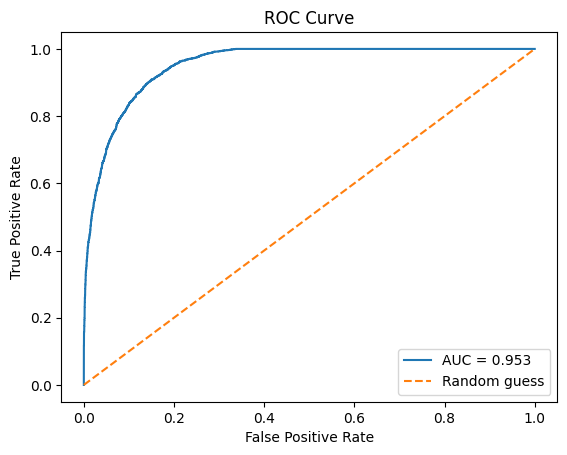

In [10]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(ytest, yprob)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## Cheat sheet — which metric to use when

| Metric | Question it answers | Use when |
|---|---|---|
| Accuracy | % correct overall | Classes are balanced |
| Precision | How many predicted positives were correct? | False positives are costly |
| Recall | How many actual positives were caught? | False negatives are costly |
| F1-score | Balance of precision and recall | Need one summary number |
| ROC-AUC | How well does the model rank positives vs negatives? | Comparing models, threshold-independent evaluation |
